In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
real_eve_data = pd.read_parquet("/home/willfaw/data/EVE/evedata_6min.parquet")
virtual_eve_data = pd.read_parquet("/home/willfaw/data/EVE/virtual_eve_6min.parquet")

In [3]:
real_eve_data.shape
real_eve_data.rename(columns={"Time": "timestamp"}, inplace=True)

In [4]:
virtual_eve_data.shape

(141902, 39)

In [6]:
real_eve_data.head()
fe_ix = real_eve_data[['timestamp', 'Fe IX']]
print(fe_ix.shape)
fe_ix = fe_ix[(fe_ix['Fe IX'] >= 0)]
print(fe_ix.shape)

fe_ix.head()

(5943, 2)
(5692, 2)


,timestamp,Fe IX
0,2010-05-01 00:00:00,0.000059
1,2010-05-01 06:00:00,0.000058
2,2010-05-01 12:00:00,0.000059
3,2010-05-01 18:00:00,0.000059
4,2010-05-02 00:00:00,0.000059


In [7]:
virtual_eve_data.head()
virt_fe_ix = virtual_eve_data[['timestamp', 'Fe_IX']]
print(virt_fe_ix.shape)
virt_fe_ix = virt_fe_ix[(virt_fe_ix['Fe_IX'] >= 0)]
print(virt_fe_ix.shape)
virt_fe_ix.head()

(141902, 2)
(141901, 2)


,timestamp,Fe_IX
50398,2010-06-01 00:12:00+00:00,0.000052
133006,2010-06-01 00:24:00+00:00,0.000052
134088,2010-06-01 00:36:00+00:00,0.000052
134549,2010-06-01 00:48:00+00:00,0.000052
90723,2010-06-01 01:00:00+00:00,0.000052


In [ ]:
# Make a plot of irradiance versus time
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fe_ix['timestamp'], fe_ix['Fe IX'], label='Real')

In [ ]:
# Make a plot of irradiance versus time
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(virt_fe_ix['timestamp'], virt_fe_ix['Fe_IX'], label='Virtual')

In [ ]:
# Make a plot of irradiance versus time
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fe_ix['timestamp'], fe_ix['Fe IX'], label='Real')
ax.plot(virt_fe_ix['timestamp'], virt_fe_ix['Fe_IX'], label='Virtual')
ax.legend()

In [50]:
# merge two dataframes
# fe_ix['timestamp'] = pd.to_datetime(fe_ix['timestamp'], utc=True)  # Convert to UTC
# fe_ix.head()

merged_df = pd.merge(fe_ix, virt_fe_ix, on='timestamp', how='inner')
print(merged_df.shape)

merged_df['ratio'] = merged_df['Fe IX'] / merged_df['Fe_IX']
merged_df['residual'] = (merged_df['Fe IX'] - merged_df['Fe_IX']) / merged_df['Fe IX']
merged_df.head()


(2299, 3)


,timestamp,Fe IX,Fe_IX,ratio,residual
0,2010-06-01 12:00:00+00:00,0.000053,0.000053,0.994233,-0.005801
1,2010-06-03 00:00:00+00:00,0.000052,0.000053,0.983767,-0.016501
2,2010-06-03 12:00:00+00:00,0.000053,0.000053,0.994016,-0.006020
3,2010-06-05 12:00:00+00:00,0.000053,0.000052,1.020639,0.020221
4,2010-06-06 00:00:00+00:00,0.000052,0.000052,0.998821,-0.001180


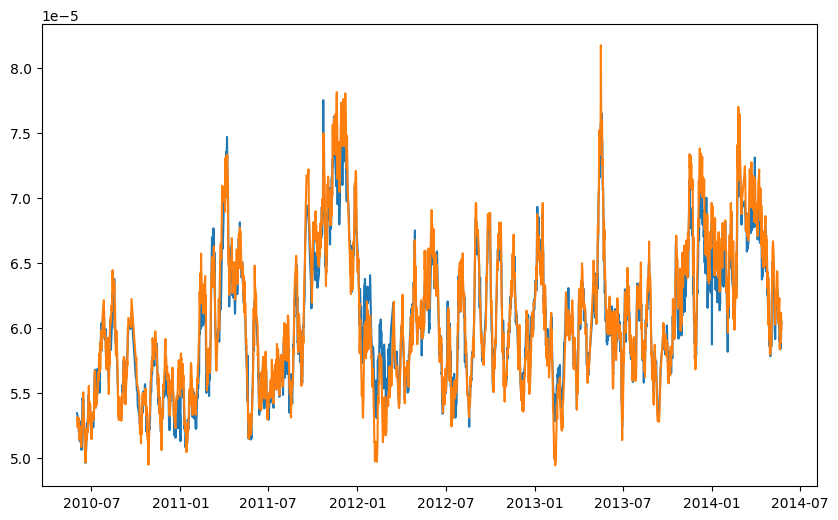

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(merged_df['timestamp'], merged_df['Fe_IX'], label='Virtual')
ax.plot(merged_df['timestamp'], merged_df['Fe IX'], label='Real')

In [30]:
def make_ratio_plot(x, y1, y2, label1, label2, ratio_y, save_path):
    # Create some sample data
    # x = np.linspace(0, 10, 100)
    # y1 = np.sin(x)
    # y2 = np.cos(x)
    # ratio_y = y1 / y2  # Ratio of y1 to y2

    # Create the main plot (top) and ratio plot (bottom)
    fig = plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1])  # Create a 2x1 grid with a height ratio of 3:1

    # Add the main plot to the top grid
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x, y1, label=label1)
    ax1.plot(x, y2, label=label2)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Irradience [Wm$^{-2}$]')
    ax1.legend()

    # Add the ratio plot to the bottom grid
    ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Share the same x-axis with the main plot
    ax2.plot(x, ratio_y, label=f'{label1}/{label2}', color='red')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Ratio')
    ax2.axhline(y=1, color='black', linestyle='--', linewidth=1)  # Add a horizontal line at y=1
    ax2.legend()

    # Adjust the spacing between the subplots
    plt.tight_layout()

    plt.savefig(save_path)
    # Show the combined plot
    plt.show()

   


In [56]:
def plot_with_residuals(x, y1, y2, residuals, label1, label2, save_path):
    ratio_y = y1 / y2  # Ratio of y1 to y2
    # residuals = (y1 - y2)/y1  # Residuals

    # Create the main plot (top), ratio plot (middle), and residuals plot (bottom)
    fig = plt.figure(figsize=(10, 12))  # Adjust the figure size as needed
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1])  # Create a 3x1 grid with height ratios

    # Add the main plot to the top grid
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x, y1, label=label1, color='red')
    ax1.plot(x, y2, label=label2, color='blue')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Irradience [Wm$^{-2}$]')
    ax1.legend()

    # Add the ratio plot to the middle grid
    ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Share the same x-axis with the main plot
    ax2.plot(x, ratio_y, label=f'{label1}/{label2}', color='black')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Ratio')
    ax2.axhline(y=1, color='black', linestyle='--', linewidth=1)  # Add a horizontal line at y=1
    ax2.legend()

    # Add the residuals plot to the bottom grid
    ax3 = fig.add_subplot(gs[2], sharex=ax1)  # Share the same x-axis with the main plot
    ax3.plot(x, residuals, label=f'({label1}-{label2})/{label1}', color='black')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Residuals')
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)  # Add a horizontal line at y=0
    ax3.legend()

    # Adjust the spacing between the subplots
    plt.tight_layout()

    plt.savefig(save_path)


    # Show the combined plot
    plt.show()

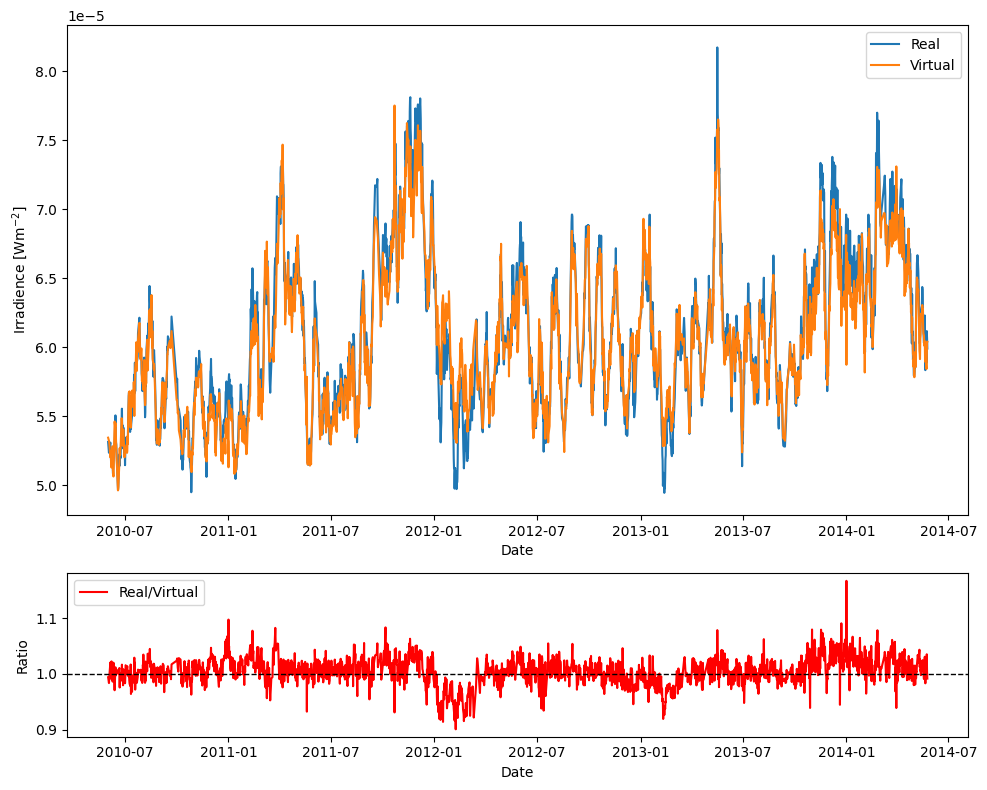

In [48]:
make_ratio_plot(
    x=merged_df['timestamp'],
    y1= merged_df['Fe IX'],
    y2=merged_df['Fe_IX'],
    label1='Real', 
    label2='Virtual',
    ratio_y=merged_df['ratio'],
    save_path="/home/willfaw/plots/ratio_plot.png"
)

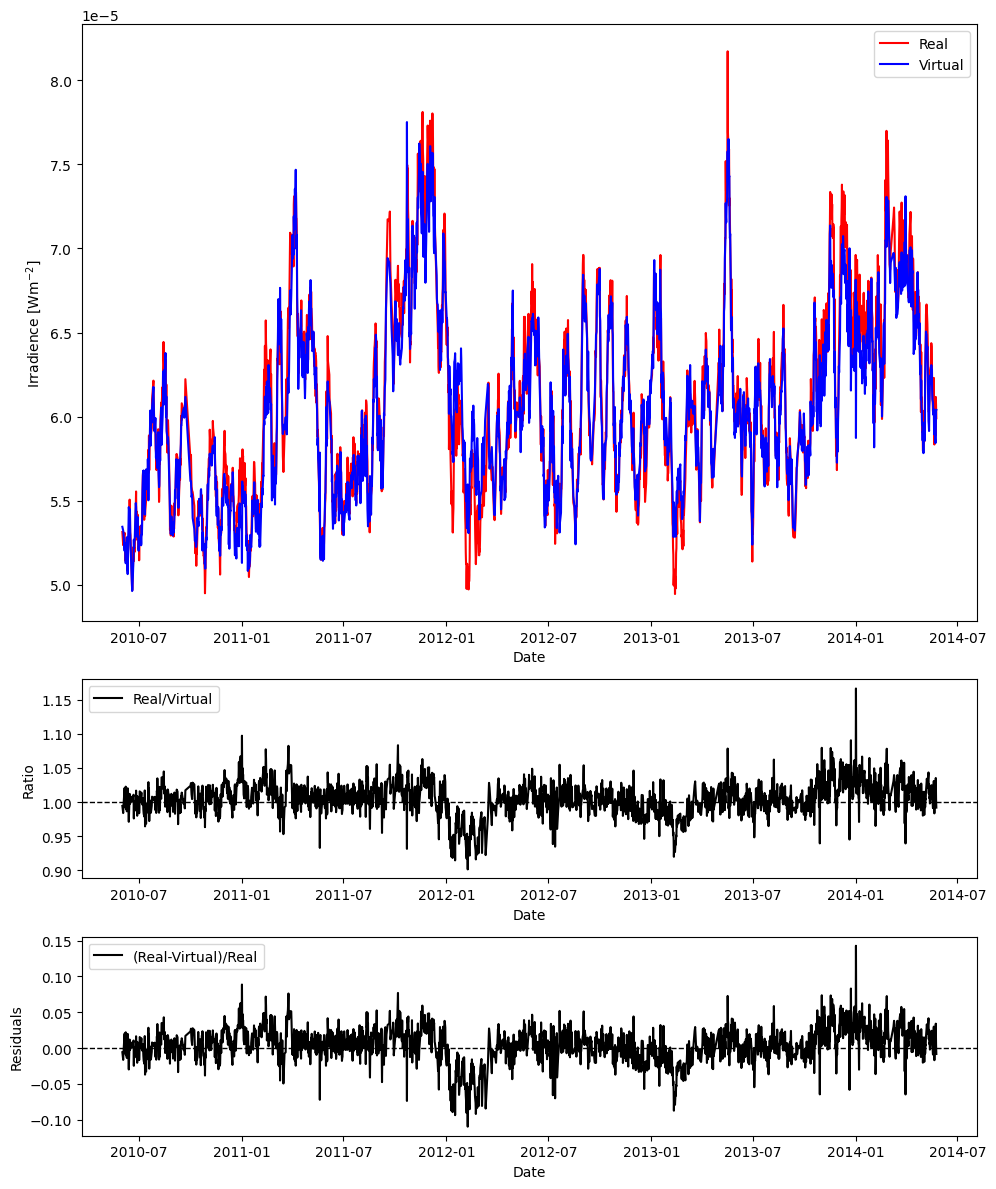

In [57]:
plot_with_residuals(
    x=merged_df['timestamp'],
    y1= merged_df['Fe IX'],
    y2=merged_df['Fe_IX'],
    residuals=merged_df['residual'],
    label1="Real",
    label2="Virtual",
    save_path="/home/willfaw/plots/ratio_plot_with_residual.png"
)

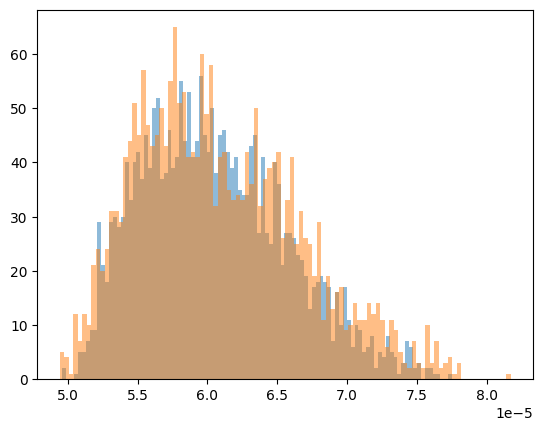

In [46]:
plt.hist(merged_df['Fe_IX'], bins=100, alpha=0.5);
plt.hist(merged_df['Fe IX'], bins=100, alpha=0.5);

In [59]:
virtual_eve_data.head()

,timestamp,C_III,Fe_IX,Fe_VIII,Fe_X,Fe_XI,Fe_XII,Fe_XIII,Fe_XIV,Fe_XIX,...,O_III,O_III_2,O_II_2,O_IV,O_IV_2,O_V,O_VI,S_XIV,Si_XII,Si_XII_2
50398,2010-06-01 00:12:00+00:00,0.000128,0.000052,0.000002,0.000033,0.000045,0.000031,0.000025,0.000012,6.675415e-07,...,0.000002,0.000005,0.000031,0.000023,0.000015,0.000047,0.000053,4.780151e-07,0.000009,0.000003
133006,2010-06-01 00:24:00+00:00,0.000127,0.000052,0.000002,0.000033,0.000045,0.000031,0.000024,0.000011,6.632675e-07,...,0.000002,0.000005,0.000031,0.000023,0.000015,0.000047,0.000053,4.873880e-07,0.000009,0.000003
134088,2010-06-01 00:36:00+00:00,0.000128,0.000052,0.000002,0.000033,0.000045,0.000031,0.000025,0.000012,6.693898e-07,...,0.000002,0.000005,0.000031,0.000023,0.000015,0.000047,0.000053,4.557576e-07,0.000009,0.000003
134549,2010-06-01 00:48:00+00:00,0.000127,0.000052,0.000002,0.000033,0.000045,0.000031,0.000025,0.000012,6.711607e-07,...,0.000002,0.000005,0.000031,0.000023,0.000015,0.000047,0.000053,4.320252e-07,0.000009,0.000003
90723,2010-06-01 01:00:00+00:00,0.000128,0.000052,0.000002,0.000033,0.000045,0.000031,0.000025,0.000012,6.737123e-07,...,0.000002,0.000005,0.000031,0.000023,0.000015,0.000047,0.000053,4.388100e-07,0.000009,0.000003


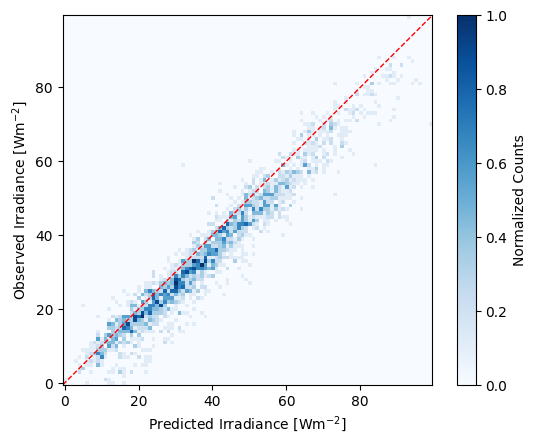

In [69]:
hist, xedges, yedges = np.histogram2d(merged_df['Fe_IX'], merged_df['Fe IX'], bins=100)

# Normalize the histogram so that the maximum value is 1
hist_normalized = hist / hist.max()

# Create a plot
plt.imshow(hist_normalized.T, origin='lower', cmap='Blues')
plt.colorbar(label='Normalized Counts')

# plt.hist2d(merged_df['Fe_IX'], merged_df['Fe IX'], bins=100, cmap='Blues');

plt.xlabel('Predicted Irradiance [Wm$^{-2}$]')
plt.ylabel('Observed Irradiance [Wm$^{-2}$]')
plt.axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1)

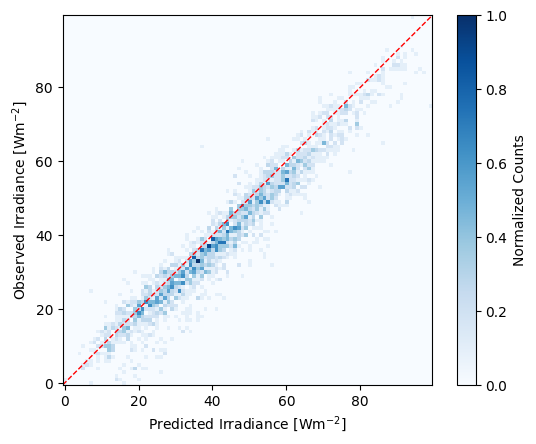

In [71]:
x = np.log(merged_df['Fe_IX'])
y = np.log(merged_df['Fe IX'])

hist, xedges, yedges = np.histogram2d(x, y, bins=100)

# Normalize the histogram so that the maximum value is 1
hist_normalized = hist / hist.max()

# Create a plot
plt.imshow(hist_normalized.T, origin='lower', cmap='Blues')
plt.colorbar(label='Normalized Counts')

# plt.hist2d(merged_df['Fe_IX'], merged_df['Fe IX'], bins=100, cmap='Blues');

plt.xlabel('Predicted Irradiance [Wm$^{-2}$]')
plt.ylabel('Observed Irradiance [Wm$^{-2}$]')
plt.axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1)

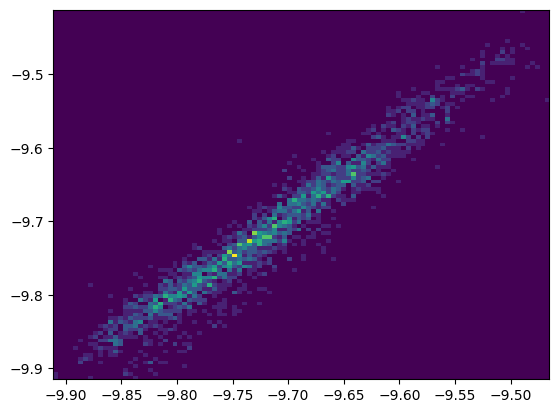

In [75]:
plt.hist2d(x,y, bins=100);

In [79]:
hist, xedges, yedges = np.histogram2d(x, y, bins=100)
hist.shape
print(hist.min(), hist.max())

0.0 11.0


In [83]:
def make_2d_hist(x_hist, y_hist, xlabel, ylabel, title, plot_log=False):

    x_hist = np.array(x_hist)
    y_hist = np.array(y_hist)

    if plot_log:
        x = np.log(x_hist)
        y = np.log(y_hist)
    else:
        x = x_hist
        y = y_hist
    
    print(f"x range: {x.min(), x.max()}")
    print(f"y range: {y.min(), y.max()}")

    hist, xedges, yedges = np.histogram2d(x, y, bins=100)

    # Normalize the histogram so that the maximum value is 1
    hist_normalized = hist / hist.max()

    # Create a plot
    plt.imshow(hist_normalized.T, origin='lower', cmap='Blues')
    plt.colorbar(label='Normalized Counts')

    # plt.hist2d(x_hist, y_hist, bins=100, cmap='Blues')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()


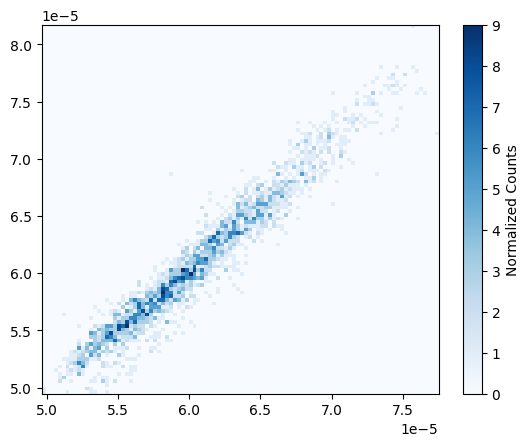

In [89]:
x = merged_df['Fe_IX']
y = merged_df['Fe IX']
# make_2d_hist(x, y, 'x', 'y', 'title', plot_log=True)
hist, xedges, yedges, image = plt.hist2d(x, y, bins=100, cmap='Blues');
hist_norm = hist / hist.max()
plt.colorbar(label='Normalized Counts')

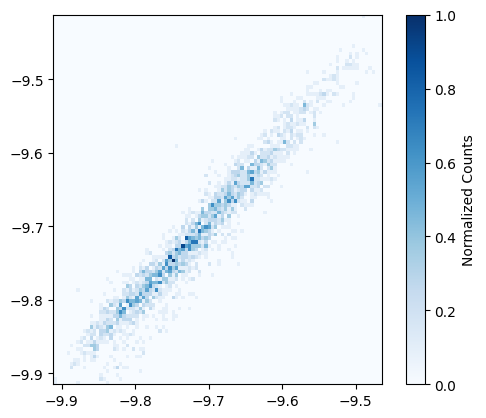

In [106]:
x = np.log(merged_df['Fe_IX'])
y = np.log(merged_df['Fe IX'])
# make_2d_hist(x, y, 'x', 'y', 'title', plot_log=True)
hist, xedges, yedges, image = plt.hist2d(x, y, bins=100, cmap='Blues')
# print(type(hist))
# print(hist.shape)
# print(hist[0].shape)
# print(type(image))
hist_normalized = hist / hist.max()
# plt.clf()
# plt.hist2d(hist_normalized[0], hist_normalized[1], cmap='Blues');
plt.imshow(hist_normalized.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='Blues')
plt.colorbar(label='Normalized Counts')
